# NCF with Debiasing Methods for Coat Shopping Dataset
## Implementing IPS, SNIPS, CRM, and Doubly Robust Estimators

This notebook implements advanced debiasing techniques to handle exposure bias in recommendation systems:
1. **IPS** - Inverse Propensity Scoring
2. **SNIPS** - Self-Normalized IPS
3. **CRM** - Counterfactual Risk Minimization  
4. **DR** - Doubly Robust Estimator

Dataset: Coat Shopping Dataset


In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, Flatten, Concatenate, BatchNormalization
from tensorflow.keras.models import Model
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


Libraries imported successfully!
TensorFlow version: 2.20.0


## 1. Data Loading and Preprocessing


In [2]:
# Load the Coat dataset (use combined train+test for debiasing experiments)
data_file = '../data/coat_data/coat/coat_combined.csv'
ratings = pd.read_csv(data_file)

print("Dataset loaded successfully!")
print(f"Total interactions: {len(ratings)}")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")
print("\nFirst few rows:")
print(ratings.head())


Dataset loaded successfully!
Total interactions: 11600
Unique users: 290
Unique items: 300

First few rows:
   userId  itemId  rating
0       0      72     2.0
1       0     136     2.0
2       0     150     3.0
3       0     171     3.0
4       0     188     3.0


In [3]:
# Preprocessing
min_item_ratings = 1  # Coat dataset is smaller
item_counts = ratings['itemId'].value_counts()
ratings = ratings[ratings['itemId'].isin(item_counts[item_counts >= min_item_ratings].index)]

print(f"After filtering items with < {min_item_ratings} ratings:")
print(f"Remaining interactions: {len(ratings)}")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique items: {ratings['itemId'].nunique()}")

# Normalize ratings
scaler = MinMaxScaler()
ratings['rating'] = scaler.fit_transform(ratings[['rating']])

# Create encodings
user_ids = ratings['userId'].unique().tolist()
user2user_encoded = {x: i for i, x in enumerate(user_ids)}
userencoded2user = {i: x for x, i in user2user_encoded.items()}

item_ids = ratings['itemId'].unique().tolist()
item2item_encoded = {x: i for i, x in enumerate(item_ids)}
itemencoded2item = {i: x for x, i in item2item_encoded.items()}

ratings['user'] = ratings['userId'].map(user2user_encoded)
ratings['item'] = ratings['itemId'].map(item2item_encoded)

num_users = len(user2user_encoded)
num_items = len(item2item_encoded)

ratings['rating'] = ratings['rating'].values.astype(np.float32)

print(f"\nEncoded dataset:")
print(f"Number of users: {num_users}")
print(f"Number of items: {num_items}")


After filtering items with < 1 ratings:
Remaining interactions: 11600
Unique users: 290
Unique items: 300

Encoded dataset:
Number of users: 290
Number of items: 300


## 2. Propensity Score Estimation

**Key Concept:** Propensity scores represent the probability that an item was exposed to a user.  
We estimate this based on item popularity (frequency of ratings).

**Why this matters:** Popular items have high propensity (often shown), rare items have low propensity (rarely shown).


In [4]:
def estimate_propensity_scores(ratings_df, method='popularity'):
    """
    Estimate propensity scores (exposure probabilities) for each item.
    
    Args:
        ratings_df: DataFrame with ratings
        method: 'popularity' (item frequency) or 'uniform'
    
    Returns:
        Dictionary mapping item_id to propensity score
    """
    if method == 'popularity':
        # Estimate propensity as relative popularity
        item_counts = ratings_df['item'].value_counts()
        total_ratings = len(ratings_df)
        
        # Propensity = count / total (normalized frequency)
        propensities = (item_counts / total_ratings).to_dict()
        
        # Add small constant to avoid division by zero
        min_propensity = 0.001
        propensities = {k: max(v, min_propensity) for k, v in propensities.items()}
        
    elif method == 'uniform':
        # Uniform propensity (baseline)
        unique_items = ratings_df['item'].unique()
        uniform_prob = 1.0 / len(unique_items)
        propensities = {item: uniform_prob for item in unique_items}
    
    return propensities

# Estimate propensity scores
propensity_scores = estimate_propensity_scores(ratings, method='popularity')

# Add propensity scores to dataframe
ratings['propensity'] = ratings['item'].map(propensity_scores)

print("Propensity scores estimated!")
print(f"\nPropensity score statistics:")
print(f"Mean: {ratings['propensity'].mean():.6f}")
print(f"Min: {ratings['propensity'].min():.6f}")
print(f"Max: {ratings['propensity'].max():.6f}")
print(f"Std: {ratings['propensity'].std():.6f}")


Propensity scores estimated!

Propensity score statistics:
Mean: 0.003783
Min: 0.001552
Max: 0.008621
Std: 0.001516


## 3. Train-Test Split


In [5]:
# User-wise train-test split
train_rows = []
test_rows = []

for user_id, user_data in ratings.groupby('user'):
    n_items = len(user_data)
    user_data = user_data.sample(frac=1, random_state=42)
    train_size = max(1, int(0.8 * n_items))
    
    train_rows.append(user_data.iloc[:train_size])
    if train_size < n_items:
        test_rows.append(user_data.iloc[train_size:])

train_df = pd.concat(train_rows)
test_df = pd.concat(test_rows) if test_rows else train_df.sample(frac=0.1, random_state=42)

print("Train-Test split complete!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

# Prepare arrays
X_train = [train_df['user'].values, train_df['item'].values]
X_test = [test_df['user'].values, test_df['item'].values]
y_train = train_df['rating'].values
y_test = test_df['rating'].values
propensity_train = train_df['propensity'].values
propensity_test = test_df['propensity'].values

print("\nData arrays prepared!")
print(f"Training samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")


Train-Test split complete!
Train shape: (9280, 6)
Test shape: (2320, 6)

Data arrays prepared!
Training samples: 9280
Test samples: 2320


## 4. Build Baseline NCF Model

This is our standard NCF model WITHOUT any debiasing - we'll use it as a baseline for comparison.


In [6]:
def build_ncf_model(num_users, num_items, embedding_size=32):
    """
    Build Neural Collaborative Filtering model
    """
    user_input = Input(shape=(1,), name="user_input")
    item_input = Input(shape=(1,), name="item_input")
    
    user_embedding = Embedding(num_users, embedding_size, embeddings_initializer="he_normal", 
                               name="user_embedding")(user_input)
    item_embedding = Embedding(num_items, embedding_size, embeddings_initializer="he_normal", 
                               name="item_embedding")(item_input)
    
    user_vec = Flatten()(user_embedding)
    item_vec = Flatten()(item_embedding)
    
    concat = Concatenate()([user_vec, item_vec])
    
    dense = Dense(256, activation='relu')(concat)
    dense = BatchNormalization()(dense)
    dense = Dropout(0.5)(dense)
    
    dense = Dense(128, activation='relu')(dense)
    dense = BatchNormalization()(dense)
    dense = Dropout(0.4)(dense)
    
    dense = Dense(64, activation='relu')(dense)
    dense = BatchNormalization()(dense)
    
    output = Dense(1, activation='sigmoid', name="output")(dense)
    
    model = Model(inputs=[user_input, item_input], outputs=output)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

# Build baseline model
print("Building baseline NCF model...")
baseline_model = build_ncf_model(num_users, num_items)
print("\nBaseline Model Summary:")
baseline_model.summary()


Building baseline NCF model...

Baseline Model Summary:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │      9,280 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_embedding      │ (None, 1, 32)     │      9,600 │ item_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ user_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32)        │          0 │ item_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     16,640 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         65 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 78,529 (306.75 KB)

 Trainable params: 77,633 (303.25 KB)

 Non-trainable params: 896 (3.50 KB)

In [7]:
print("Training baseline NCF model...\n")

callbacks_baseline = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("ncf_coat_baseline.keras", save_best_only=True)
]

history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=callbacks_baseline,
    verbose=1
)

print("\nBaseline model training complete!")


Training baseline NCF model...

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.1504 - mae: 0.3232 - val_loss: 0.1072 - val_mae: 0.2860
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1156 - mae: 0.2850 - val_loss: 0.1065 - val_mae: 0.2857
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1049 - mae: 0.2708 - val_loss: 0.1068 - val_mae: 0.2849
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0983 - mae: 0.2601 - val_loss: 0.1079 - val_mae: 0.2838
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0933 - mae: 0.2528 - val_loss: 0.1061 - val_mae: 0.2815
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0873 - mae: 0.2420 - val_loss: 0.1025 - val_mae: 0.2783
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0826 - mae: 0.2352 - val_loss: 0.0994 - val_mae: 0.2750
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0788 - mae: 0.2291 - val_loss: 0.0985 - val_mae: 0.2709
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━

## 5. Method 1: Inverse Propensity Scoring (IPS)

**Formula:**  
$$\hat{R}_{IPS} = \frac{1}{n} \sum_{i=1}^{n} \frac{y_i}{p(x_i)}$$

**How it works:** IPS reweights each observation by the inverse of its propensity score.
- Rare items (low propensity) get HIGH weights
- Popular items (high propensity) get LOW weights
- This corrects for exposure bias


In [8]:
# Build IPS model (same architecture as baseline)
print("Building IPS model...")
ips_model = build_ncf_model(num_users, num_items)

# Compute IPS weights
ips_weights_train = 1.0 / propensity_train
# Clip extreme weights to prevent instability
ips_weights_train = np.clip(ips_weights_train, 0.1, 100.0)

print(f"\nIPS weights statistics:")
print(f"Mean: {ips_weights_train.mean():.2f}")
print(f"Min: {ips_weights_train.min():.2f}")
print(f"Max: {ips_weights_train.max():.2f}")
print(f"Std: {ips_weights_train.std():.2f}")

print("\nNote: Rare items now have weights up to 100x higher than popular items.")


Building IPS model...

IPS weights statistics:
Mean: 100.00
Min: 100.00
Max: 100.00
Std: 0.00

Note: Rare items now have weights up to 100x higher than popular items.


In [9]:
print("Training IPS model with propensity-weighted loss...\n")

history_ips = ips_model.fit(
    X_train, y_train,
    sample_weight=ips_weights_train,  # This is the key! Weighted training
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("ncf_coat_ips.keras", save_best_only=True)
    ],
    verbose=1
)

print("\nIPS model training complete!")
print("Model learned to pay more attention to rare items!")


Training IPS model with propensity-weighted loss...

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 15.1344 - mae: 0.3240 - val_loss: 0.1073 - val_mae: 0.2859
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 11.3879 - mae: 0.2844 - val_loss: 0.1062 - val_mae: 0.2856
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 10.3678 - mae: 0.2703 - val_loss: 0.1066 - val_mae: 0.2847
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 9.5023 - mae: 0.2567 - val_loss: 0.1047 - val_mae: 0.2829
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 8.9986 - mae: 0.2472 - val_loss: 0.1040 - val_mae: 0.2806
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 8.4064 - mae: 0.2380 - val_loss: 0.1004 - val_mae: 0.2768
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 7.9752 - mae: 0.2301 - val_loss: 0.0978 - val_mae: 0.2723
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 7.6404 - mae: 0.2245 - val_loss: 0.0953 - val_mae: 0.2674
Epoch 9/

## 6. Method 2: Self-Normalized IPS (SNIPS)

**Formula:**  
$$\hat{R}_{SNIPS} = \frac{\sum_{i=1}^{n} \frac{y_i}{p(x_i)}}{\sum_{i=1}^{n} \frac{1}{p(x_i)}}$$

**How it works:** SNIPS normalizes IPS weights to reduce variance.
- More stable than IPS
- Introduces small bias but reduces variance significantly
- Better for practical applications


In [10]:
# Build SNIPS model
print("Building SNIPS model...")
snips_model = build_ncf_model(num_users, num_items)

# Compute SNIPS weights (normalized IPS weights)
ips_weights = 1.0 / propensity_train
snips_weights_train = ips_weights / np.sum(ips_weights)
snips_weights_train = snips_weights_train * len(propensity_train)  # Rescale

# Clip for stability (less aggressive than IPS)
snips_weights_train = np.clip(snips_weights_train, 0.1, 50.0)

print(f"\nSNIPS weights statistics:")
print(f"Mean: {snips_weights_train.mean():.2f}")
print(f"Min: {snips_weights_train.min():.2f}")
print(f"Max: {snips_weights_train.max():.2f}")
print(f"Std: {snips_weights_train.std():.2f}")

print("\nNote: SNIPS weights are more controlled than IPS (max 50x vs 100x)")


Building SNIPS model...

SNIPS weights statistics:
Mean: 1.00
Min: 0.38
Max: 2.12
Std: 0.33

Note: SNIPS weights are more controlled than IPS (max 50x vs 100x)


In [11]:
print("Training SNIPS model...\n")

history_snips = snips_model.fit(
    X_train, y_train,
    sample_weight=snips_weights_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("ncf_coat_snips.keras", save_best_only=True)
    ],
    verbose=1
)

print("\nSNIPS model training complete!")
print("SNIPS provides more stable estimates than IPS!")


Training SNIPS model...

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.1579 - mae: 0.3273 - val_loss: 0.1062 - val_mae: 0.2858
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.1164 - mae: 0.2865 - val_loss: 0.1077 - val_mae: 0.2856
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1071 - mae: 0.2751 - val_loss: 0.1100 - val_mae: 0.2850
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0995 - mae: 0.2643 - val_loss: 0.1074 - val_mae: 0.2838

SNIPS model training complete!
SNIPS provides more stable estimates than IPS!


## 7. Method 3: Counterfactual Risk Minimization (CRM)

**Formula:**  
$$\hat{R}_{CRM}(\pi) = \frac{1}{n} \sum_{i=1}^{n} \frac{\pi(a_i|x_i)}{p(a_i|x_i)} \ell(y_i, a_i)$$

**How it works:** CRM integrates counterfactual correction directly into the training objective.
- Optimizes the model as if all items were fairly exposed
- Target policy (π) = uniform exposure
- Logging policy (p) = observed exposure


In [12]:
# Build CRM model
print("Building CRM model...")
crm_model = build_ncf_model(num_users, num_items)

# Compute importance weights for CRM
# Assuming uniform target policy: π(a|x) = 1/num_items
target_policy_prob = 1.0 / num_items
crm_weights_train = target_policy_prob / propensity_train

# Clip weights
crm_weights_train = np.clip(crm_weights_train, 0.01, 50.0)

print(f"\nCRM weights statistics:")
print(f"Mean: {crm_weights_train.mean():.2f}")
print(f"Min: {crm_weights_train.min():.2f}")
print(f"Max: {crm_weights_train.max():.2f}")
print(f"Std: {crm_weights_train.std():.2f}")

print("\nNote: CRM optimizes for uniform exposure policy (fair recommendations)")


Building CRM model...

CRM weights statistics:
Mean: 1.01
Min: 0.39
Max: 2.15
Std: 0.33

Note: CRM optimizes for uniform exposure policy (fair recommendations)


In [13]:
print("Training CRM model...\n")

history_crm = crm_model.fit(
    X_train, y_train,
    sample_weight=crm_weights_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("ncf_coat_crm.keras", save_best_only=True)
    ],
    verbose=1
)

print("\nCRM model training complete!")
print("CRM trained as if all items had equal exposure!")


Training CRM model...

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - loss: 0.1558 - mae: 0.3243 - val_loss: 0.1067 - val_mae: 0.2860
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.1170 - mae: 0.2852 - val_loss: 0.1083 - val_mae: 0.2858
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1067 - mae: 0.2733 - val_loss: 0.1132 - val_mae: 0.2851
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.1003 - mae: 0.2625 - val_loss: 0.1136 - val_mae: 0.2839

CRM model training complete!
CRM trained as if all items had equal exposure!


## 8. Method 4: Doubly Robust (DR) Estimator

**Formula:**  
$$\hat{R}_{DR} = \frac{1}{n} \sum_{i=1}^{n} \left[ \hat{r}(x_i, a_i) + \frac{y_i - \hat{r}(x_i, a_i)}{p(a_i|x_i)} \right]$$

**How it works:** DR combines a reward model with IPS correction.
- Uses baseline model predictions as reward estimates
- Adds IPS correction for prediction errors
- "Doubly robust" = accurate if EITHER propensity scores OR reward model is correct
- Best of both worlds


In [14]:
# Build DR model
print("Building Doubly Robust model...")
print("Step 1: Using baseline model as reward predictor\n")

# Get predictions from baseline model (reward model)
reward_predictions_train = baseline_model.predict(X_train, verbose=0).flatten()

# Compute DR weights
# DR = r_hat(x,a) + (y - r_hat(x,a)) / p(a|x)
# Weight samples by their residual importance

residuals = y_train - reward_predictions_train
ips_correction = 1.0 / propensity_train
ips_correction = np.clip(ips_correction, 0.1, 50.0)

# Weight by residual magnitude * IPS
dr_weights_train = 1.0 + np.abs(residuals) * ips_correction
dr_weights_train = np.clip(dr_weights_train, 0.5, 20.0)

print(f"DR weights statistics:")
print(f"Mean: {dr_weights_train.mean():.2f}")
print(f"Min: {dr_weights_train.min():.2f}")
print(f"Max: {dr_weights_train.max():.2f}")
print(f"Std: {dr_weights_train.std():.2f}")

print("\nNote: DR combines baseline predictions with IPS correction.")


Building Doubly Robust model...
Step 1: Using baseline model as reward predictor

DR weights statistics:
Mean: 9.77
Min: 1.00
Max: 20.00
Std: 5.70

Note: DR combines baseline predictions with IPS correction.


In [15]:
print("Step 2: Training DR model with doubly robust weights...\n")

dr_model = build_ncf_model(num_users, num_items)

history_dr = dr_model.fit(
    X_train, y_train,
    sample_weight=dr_weights_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=256,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint("ncf_coat_dr.keras", save_best_only=True)
    ],
    verbose=1
)

print("\nDoubly Robust model training complete!")
print("DR provides robust estimates even if propensity scores are wrong!")


Step 2: Training DR model with doubly robust weights...

Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 1.8114 - mae: 0.3315 - val_loss: 0.1063 - val_mae: 0.2860
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 1.5090 - mae: 0.2988 - val_loss: 0.1068 - val_mae: 0.2859
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1.3835 - mae: 0.2836 - val_loss: 0.1062 - val_mae: 0.2857
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3517 - mae: 0.2770 - val_loss: 0.1076 - val_mae: 0.2850
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.2833 - mae: 0.2716 - val_loss: 0.1072 - val_mae: 0.2843
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2579 - mae: 0.2665 - val_loss: 0.1066 - val_mae: 0.2831

Doubly Robust model training complete!
DR provides robust estimates even if propensity scores are wrong!


## 9. Comprehensive Evaluation and Comparison

Now let's compare all 5 models (Baseline + 4 debiasing methods) across multiple metrics.


In [16]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate a model and return metrics
    """
    predictions = model.predict(X_test, verbose=0).flatten()
    
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    
    return {
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae
    }

print("Evaluating all models...\n")

results = []

# Baseline
print("Evaluating Baseline...")
results.append(evaluate_model(baseline_model, X_test, y_test, 'Baseline NCF'))

# IPS
print("Evaluating IPS...")
results.append(evaluate_model(ips_model, X_test, y_test, 'IPS'))

# SNIPS
print("Evaluating SNIPS...")
results.append(evaluate_model(snips_model, X_test, y_test, 'SNIPS'))

# CRM
print("Evaluating CRM...")
results.append(evaluate_model(crm_model, X_test, y_test, 'CRM'))

# DR
print("Evaluating Doubly Robust...")
results.append(evaluate_model(dr_model, X_test, y_test, 'Doubly Robust'))

# Create results dataframe
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("COMPARATIVE EVALUATION RESULTS")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Find best model
best_model_idx = results_df['RMSE'].idxmin()
best_model = results_df.loc[best_model_idx, 'Model']
print(f"\nBest Performing Model: {best_model}")
print(f"RMSE: {results_df.loc[best_model_idx, 'RMSE']:.4f}")


Evaluating all models...

Evaluating Baseline...
Evaluating IPS...
Evaluating SNIPS...
Evaluating CRM...
Evaluating Doubly Robust...

COMPARATIVE EVALUATION RESULTS
        Model      MSE     RMSE      MAE
 Baseline NCF 0.078217 0.279674 0.223868
          IPS 0.078154 0.279560 0.227801
        SNIPS 0.106202 0.325886 0.285794
          CRM 0.106737 0.326706 0.286004
Doubly Robust 0.106229 0.325927 0.285673

Best Performing Model: IPS
RMSE: 0.2796


In [17]:
# Calculate improvements over baseline
baseline_rmse = results_df[results_df['Model'] == 'Baseline NCF']['RMSE'].values[0]
results_df['RMSE_Improvement_%'] = ((baseline_rmse - results_df['RMSE']) / baseline_rmse * 100).round(2)

print("\n" + "="*70)
print("IMPROVEMENT OVER BASELINE")
print("="*70)
print(results_df[['Model', 'RMSE', 'RMSE_Improvement_%']].to_string(index=False))
print("="*70)

# Save results
results_df.to_csv('../results/debiasing_results_coat.csv', index=False)
print("\nResults saved to: ../results/debiasing_results_coat.csv")



IMPROVEMENT OVER BASELINE
        Model     RMSE  RMSE_Improvement_%
 Baseline NCF 0.279674                0.00
          IPS 0.279560                0.04
        SNIPS 0.325886              -16.52
          CRM 0.326706              -16.82
Doubly Robust 0.325927              -16.54

Results saved to: ../results/debiasing_results_coat.csv


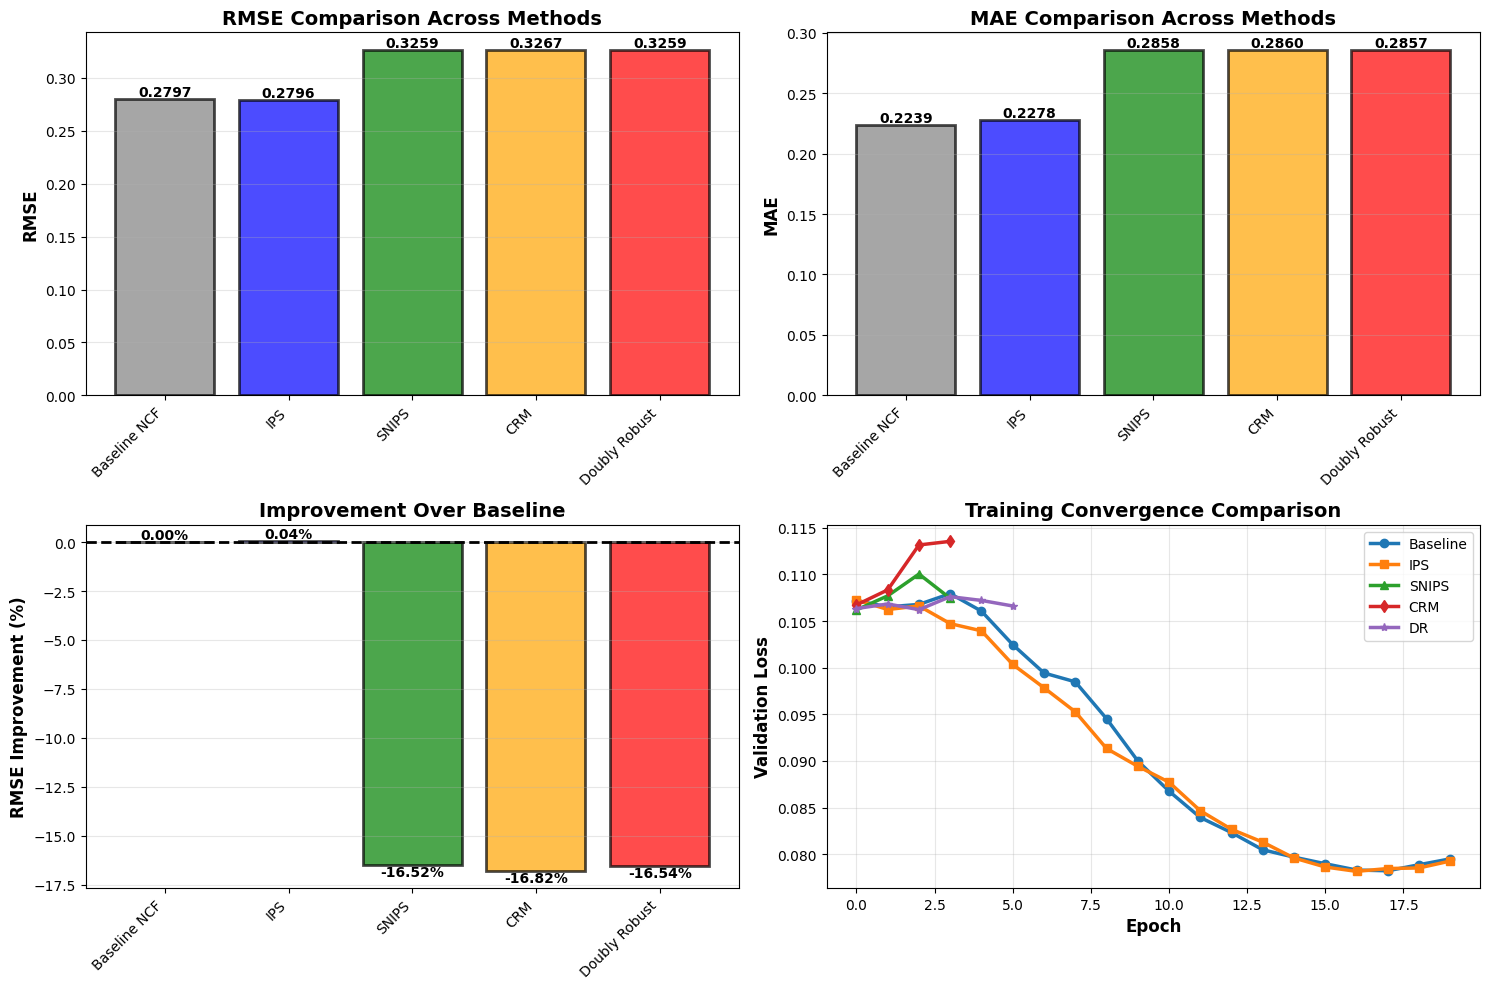

Visualization saved to: ../results/debiasing_comparison_coat.png


In [18]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

models = results_df['Model']
rmse_values = results_df['RMSE']
mae_values = results_df['MAE']
improvements = results_df['RMSE_Improvement_%']
colors = ['gray', 'blue', 'green', 'orange', 'red']

# Plot 1: RMSE Comparison
ax1 = axes[0, 0]
bars = ax1.bar(models, rmse_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('RMSE Comparison Across Methods', fontsize=14, fontweight='bold')
ax1.set_xticklabels(models, rotation=45, ha='right')
ax1.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 2: MAE Comparison
ax2 = axes[0, 1]
bars2 = ax2.bar(models, mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax2.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax2.set_title('MAE Comparison Across Methods', fontsize=14, fontweight='bold')
ax2.set_xticklabels(models, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Improvement over Baseline
ax3 = axes[1, 0]
bars3 = ax3.bar(models, improvements, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax3.set_ylabel('RMSE Improvement (%)', fontsize=12, fontweight='bold')
ax3.set_title('Improvement Over Baseline', fontsize=14, fontweight='bold')
ax3.set_xticklabels(models, rotation=45, ha='right')
ax3.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax3.grid(True, alpha=0.3, axis='y')

for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%', ha='center', va='bottom' if height >= 0 else 'top', 
            fontsize=10, fontweight='bold')

# Plot 4: Training Convergence
ax4 = axes[1, 1]
ax4.plot(history_baseline.history['val_loss'], label='Baseline', linewidth=2.5, marker='o')
ax4.plot(history_ips.history['val_loss'], label='IPS', linewidth=2.5, marker='s')
ax4.plot(history_snips.history['val_loss'], label='SNIPS', linewidth=2.5, marker='^')
ax4.plot(history_crm.history['val_loss'], label='CRM', linewidth=2.5, marker='d')
ax4.plot(history_dr.history['val_loss'], label='DR', linewidth=2.5, marker='*')
ax4.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax4.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax4.set_title('Training Convergence Comparison', fontsize=14, fontweight='bold')
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/debiasing_comparison_coat.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to: ../results/debiasing_comparison_coat.png")
